In [ ]:
import sys
from pathlib import Path

# Project root is one level up from notebooks/
_proj_root = Path.cwd().parent
if str(_proj_root / 'src') not in sys.path:
    sys.path.insert(0, str(_proj_root / 'src'))

DATA_DIR = str(_proj_root / 'data')
print(f'Project root: {_proj_root}')
print(f'src in sys.path: {str(_proj_root / "src") in sys.path}')


In [1]:
import math
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from tabulate import tabulate

from data_loader import load_dataset, print_dataset_summary
from helpers import (
    divide_graph_into_parts,
    calculate_cell_weights,
    plot_cell_weights,
    print_weight_summary,
    suggest_parameters,
    print_parameter_suggestions,
)
from qubo_builder import (
    build_qubo,
    evaluate_solution,
    calibrate_alphas,
    print_qubo_diagnostics,
    brute_force_ranking,
)
from qaoa_builder import run_qaoa, run_qaoa_mps, print_qaoa_results
from cell_pruner import (
    prune_cells,
    remap_qubo_for_qaoa,
    translate_results,
    compute_solo_scores,
)
from itertools import combinations

In [2]:
import os
# ─────────────────────────────────────────────────────────────────────────────
# 1. Load dataset from Excel
# ─────────────────────────────────────────────────────────────────────────────
# Change this path to switch datasets:
#   dataset_small_city.xlsx    — 15 POIs, m=4 (brute-force feasible)
#   dataset_medium_city.xlsx   — 25 POIs, m=5 (pruning + GA territory)
#   dataset_large_city.xlsx    — 40 POIs, m=7 (MPS-QAOA territory)
#   dataset_metro_region.xlsx  — 59 POIs, m=10 (stress test)

DATASET_FILE = os.path.join(DATA_DIR, "dataset_medium_city.xlsx")

data = load_dataset(DATASET_FILE)
print_dataset_summary(data)

# Unpack
points_of_interest       = data['pois']
existing_charging_points = data['existing_chargers']
gas_stations             = data['gas_stations']
M                        = data['m']
X_MIN, X_MAX             = data['x_min'], data['x_max']
Y_MIN, Y_MAX             = data['y_min'], data['y_max']

# Grid and weight parameters
SCALE_FACTOR = 5.0
MIN_WEIGHT   = 0.5
N_QUBITS     = 256  # Change per dataset: 100/196/256/400/625/900

Dataset: medium_city
  25 POIs, 6 clusters + corridors, m=5. Tests pruning at 144-400 cells.
  Area: [0.0, 28.0] × [0.0, 27.0]
  POIs: 25  |  Chargers: 6  |  Gas: 5  |  m=5
  Density range: [0.30, 0.97]  mean=0.56


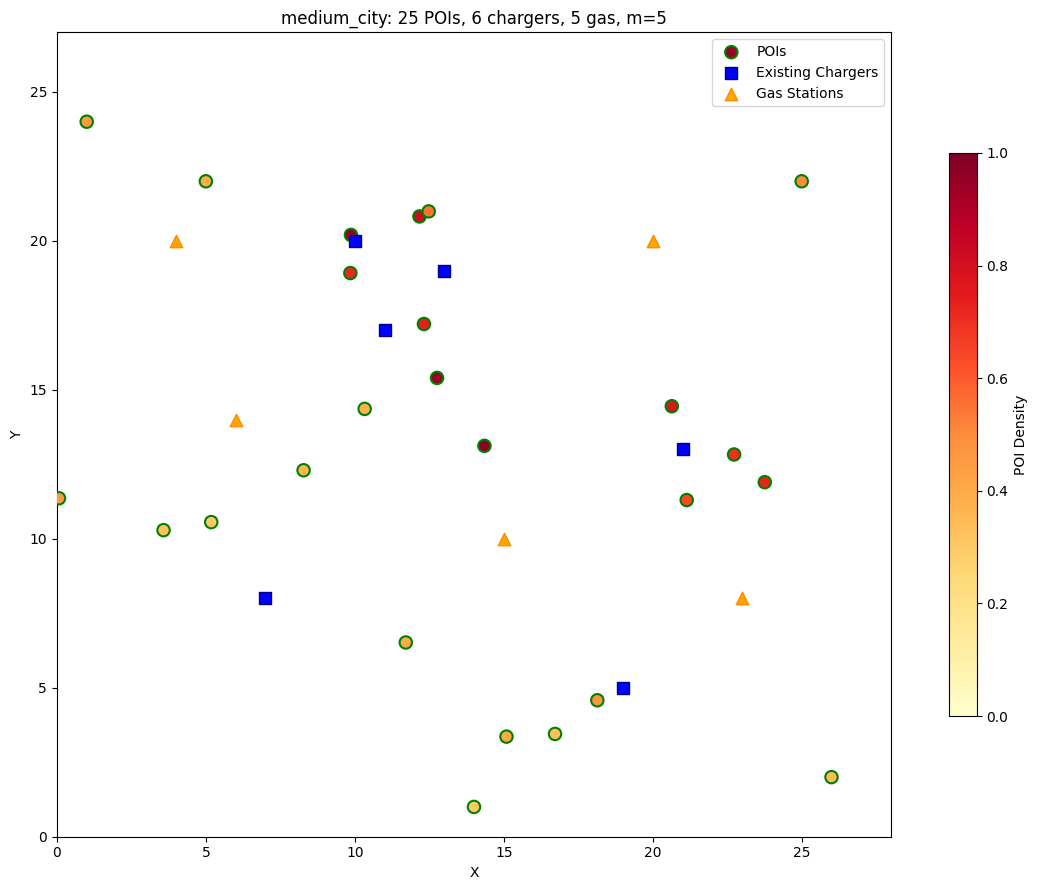

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. Input data visualization
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 9))
sc = ax.scatter(
    [p[0] for p in points_of_interest],
    [p[1] for p in points_of_interest],
    c=[p[2] for p in points_of_interest],
    cmap='YlOrRd', edgecolors='green', linewidths=1.5,
    s=80, vmin=0, vmax=1, zorder=5, label='POIs',
)
plt.colorbar(sc, ax=ax, label='POI Density', shrink=0.7)

if existing_charging_points:
    ax.scatter(*zip(*existing_charging_points), color='blue', marker='s',
               s=80, zorder=5, edgecolors='darkblue', linewidths=1, label='Existing Chargers')
if gas_stations:
    ax.scatter(*zip(*gas_stations), color='orange', marker='^',
               s=80, zorder=5, edgecolors='darkorange', linewidths=1, label='Gas Stations')

ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title(f"{data['dataset_name']}: {len(points_of_interest)} POIs, "
             f"{len(existing_charging_points)} chargers, {len(gas_stations)} gas, m={M}")
ax.legend(loc='upper right')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

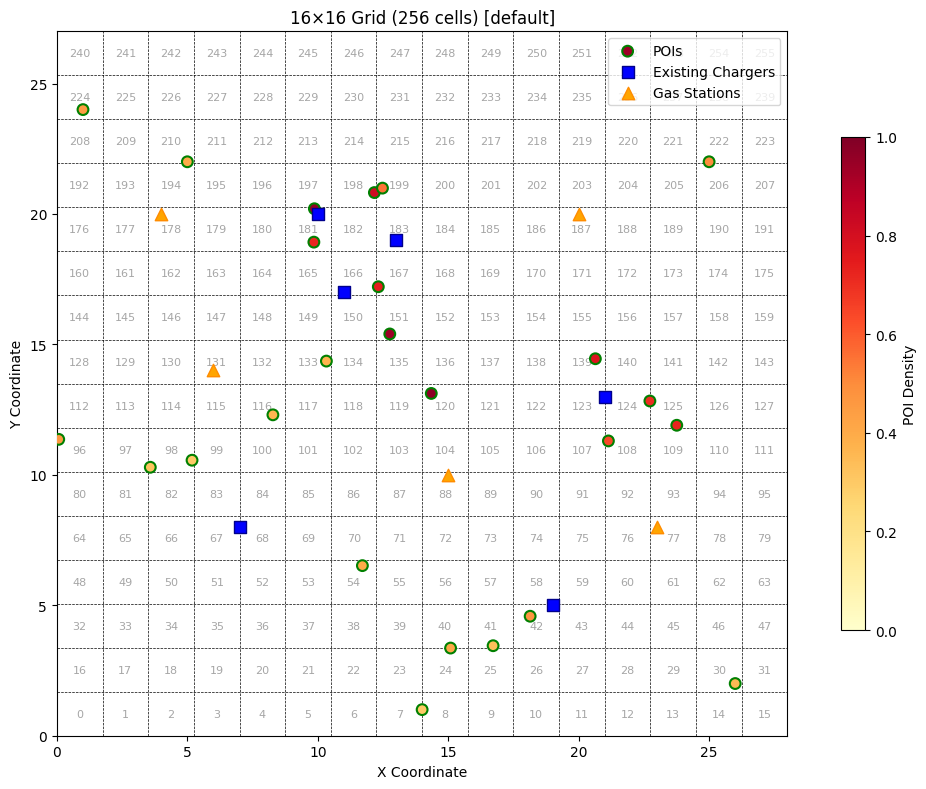

  Grid Info:
    Grid    8 (row=0, col=8): 1 POI(s) [densities: 0.30]
    Grid   24 (row=1, col=8): 1 POI(s) [densities: 0.41]
    Grid   30 (row=1, col=14): 1 POI(s) [densities: 0.35]
    Grid   41 (row=2, col=9): 1 POI(s) [densities: 0.33]
    Grid   42 (row=2, col=10): 1 POI(s) [densities: 0.47] | 1 charger(s)
    Grid   54 (row=3, col=6): 1 POI(s) [densities: 0.40]
    Grid   68 (row=4, col=4): 1 charger(s)
    Grid   77 (row=4, col=13): 1 gas station(s)
    Grid   88 (row=5, col=8): 1 gas station(s)
    Grid   96 (row=6, col=0): 1 POI(s) [densities: 0.46]
    Grid   98 (row=6, col=2): 2 POI(s) [densities: 0.32, 0.30]
    Grid  108 (row=6, col=12): 1 POI(s) [densities: 0.64]
    Grid  116 (row=7, col=4): 1 POI(s) [densities: 0.36]
    Grid  120 (row=7, col=8): 1 POI(s) [densities: 0.97]
    Grid  124 (row=7, col=12): 1 POI(s) [densities: 0.70] | 1 charger(s)
    Grid  125 (row=7, col=13): 1 POI(s) [densities: 0.73]
    Grid  131 (row=8, col=3): 1 gas station(s)
    Grid  133 (row=8

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. Grid discretization
# ─────────────────────────────────────────────────────────────────────────────

grid_details, plot_deets = divide_graph_into_parts(
    x_min=X_MIN, x_max=X_MAX, y_min=Y_MIN, y_max=Y_MAX,
    num_qubits=N_QUBITS,
    points_of_interest=points_of_interest,
    existing_chargers=existing_charging_points,
    gas_stations=gas_stations,
    grid_division="default",
)

CELL WEIGHT SUMMARY
------------------------  ---------
Total cells               256
Cells with POIs           23 (9.0%)
Total aggregated density  13.96
Max weight                5.00
Min non-zero weight       0.89
Total gas stations        5
Total existing chargers   6
------------------------  ---------

TOP 15 CELLS BY WEIGHT (Grid Data Table):
  Grid ID    Row    Col    # POIs    Raw    Norm    Weight    Gas Sta.    Chargers
---------  -----  -----  --------  -----  ------  --------  ----------  ----------
      181     11      5         2   1.68   1         5               0           1
      120      7      8         1   0.97   0.577     2.887           0           0
      151      9      7         1   0.94   0.56      2.798           0           0
      198     12      6         1   0.82   0.488     2.44            0           0
      139      8     11         1   0.77   0.458     2.292           0           0
      167     10      7         1   0.74   0.44      2.202          

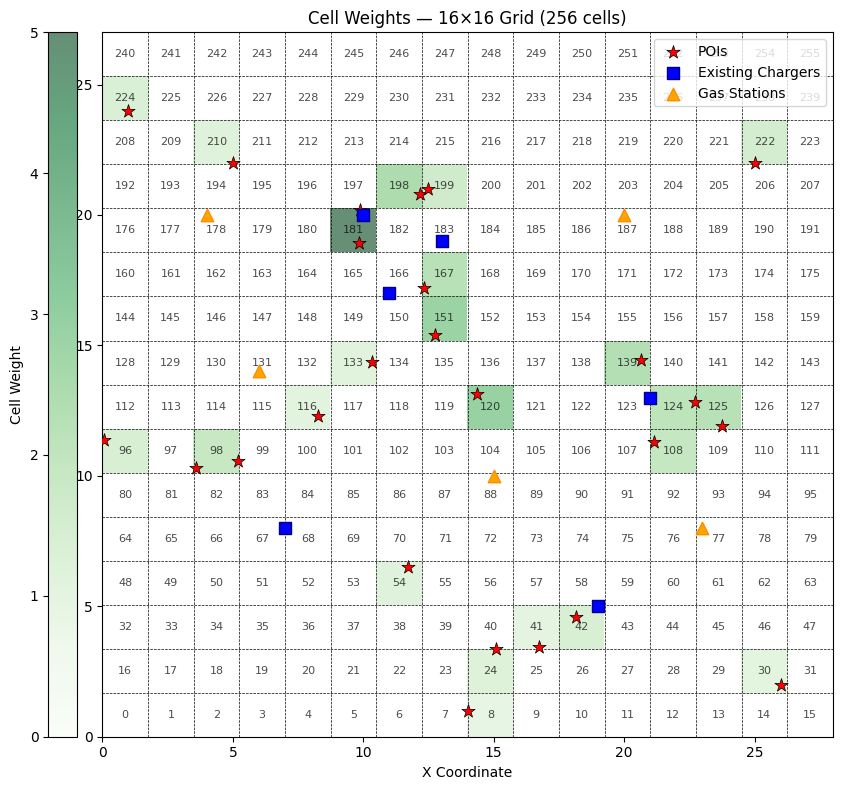

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. Cell weight calculation
# ─────────────────────────────────────────────────────────────────────────────

cell_weights = calculate_cell_weights(
    grid_details, scale_factor=SCALE_FACTOR, min_weight=MIN_WEIGHT
)
print_weight_summary(cell_weights, grid_details, top_n=15)

plot_cell_weights(
    plot_deets, grid_details, cell_weights,
    points_of_interest=points_of_interest,
    existing_chargers=existing_charging_points,
    gas_stations=gas_stations,
    show_data_points=True, show_weight_values=True,
    cell_cmap='Greens', poi_style='solid_red',
)

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. Parameter suggestion (FA-002)
# ─────────────────────────────────────────────────────────────────────────────

params = suggest_parameters(grid_details, cell_weights, plot_deets, m=M)
print_parameter_suggestions(params)

a = params['alpha']
r = params['radii']
t = params['intra']
lambda_val = params['lambda']

SUGGESTED PARAMETERS

Local Radii:
Radius                                      Value
----------------------------------------  -------
R₁  — H1 POI attraction radius                  4
Rₛ  — service gap radius (matches R₁)           4
R₃  — H3 existing charger penalty radius        2
R₄  — H4 new charger spacing radius             3
R₆  — H6 coverage redundancy radius             2

Objective Weights (α):
Parameter                                     Value
------------------------------------------  -------
α₁  — H1 POI attraction         [dominant]    3
α₂  — H2 gas station bonus                    0.5
α₃  — H3 existing charger penalty             1.23
α₄  — H4 new charger spacing                  1.5
α₅  — H5 constraint  (applied to λ)           1
α₆  — H6 coverage redundancy                  0.354

Intra-term Magnitudes:
Parameter                                  Value
---------------------------------------  -------
β  — gas station bonus magnitude               1
γ  — existing cha

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. QUBO construction
# ─────────────────────────────────────────────────────────────────────────────

Q_obj, h5_params, diags = build_qubo(
    grid_details, cell_weights, plot_deets, m=M,
    alpha1=a['a1'], alpha2=a['a2'], alpha3=a['a3'],
    alpha4=a['a4'], alpha5=a['a5'], alpha6=a['a6'],
    beta=t['beta'], gamma=t['gamma'], delta=t['delta'], epsilon=t['epsilon'],
    lam=lambda_val,
    R1=r['R1'], Rs=r['Rs'], R3=r['R3'], R4=r['R4'], R6=r['R6'],
)

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. Post-build calibration
# ─────────────────────────────────────────────────────────────────────────────

params_flat = {
    'alpha1': a['a1'], 'alpha2': a['a2'], 'alpha3': a['a3'],
    'alpha4': a['a4'], 'alpha5': a['a5'], 'alpha6': a['a6'],
    'beta': t['beta'], 'gamma': t['gamma'], 'delta': t['delta'], 'epsilon': t['epsilon'],
    'lam': lambda_val,
    'R1': r['R1'], 'Rs': r['Rs'], 'R3': r['R3'], 'R4': r['R4'], 'R6': r['R6'],
}

params_flat, needs_rebuild = calibrate_alphas(Q_obj, params_flat, diags, verbose=True)
if needs_rebuild:
    print("\nRebuilding Q_obj with calibrated parameters...")
    Q_obj, h5_params, diags = build_qubo(
        grid_details, cell_weights, plot_deets, m=M, **params_flat,
    )
    print("Rebuild complete.")

print_qubo_diagnostics(diags, params=params_flat)

CALIBRATE_ALPHAS
  Diagonal peak:  3.0000
  Target (×0.5): 1.5000
  H4 actual peak: 0.7500  ✓ OK
  H6 actual peak: 1.5002  ✓ OK
  → No rebuild needed.
QUBO CONSTRUCTION DIAGNOSTICS (Q_obj — H1 through H6, H5 separate)

Grid:  N=256 cells,  m=5 new chargers
  POI cells:            23
  Cells w/ chargers:    6
  Individual chargers:  6  (E_all — counts: {68: 1, 166: 1, 42: 1, 181: 1, 183: 1, 124: 1})
  Radii: R1=4, Rs=4, R3=2, R4=3, R6=2

Call parameters:
  alpha1       = 3.0
  alpha2       = 0.5
  alpha3       = 1.23
  alpha4       = 1.5
  alpha5       = 1.0
  alpha6       = 0.354
  beta         = 1.0
  gamma        = 1.0
  delta        = 1.0
  epsilon      = 1.0
  lam          = 87.5
  R1           = 4
  Rs           = 4
  R3           = 2
  R4           = 3
  R6           = 2

NORMALIZATION SCALES (raw max-abs, divisor applied before α):
  H1 : scale=4.01960  raw range [-4.0196, +0.0000]
  H2 : scale=1.00000  raw range [-1.0000, -0.0000]
  H3 : scale=2.00000  raw range [+0.0000, +2.00

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. Brute force on full Q (only if feasible — skip for large grids)
# ─────────────────────────────────────────────────────────────────────────────

n_combos = math.comb(N_QUBITS, M)
print(f"C({N_QUBITS},{M}) = {n_combos:,}")

if n_combos <= 500_000:
    top_solutions = brute_force_ranking(Q_obj, N=N_QUBITS, m=M, top_k=10)
    print(f"\nTOP 10 solutions (full Q):")
    for rank, (score, sol) in enumerate(top_solutions, 1):
        print(f"  {rank:>2}. score={score:>8.4f}  cells={list(sol)}")
    full_optimal_score = top_solutions[0][0]
    full_optimal_cells = set(top_solutions[0][1])
else:
    print(f"Too large for brute force — skipping.")
    top_solutions = None
    full_optimal_score = None
    full_optimal_cells = None

C(256,5) = 8,809,549,056
Too large for brute force — skipping.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. Cell Pruning
# ─────────────────────────────────────────────────────────────────────────────

surviving_cells, prune_report = prune_cells(
    Q_obj, N=N_QUBITS, m=M,
    num_cols=plot_deets['num_cols'],
    R4=r['R4'],
    tier3_keep=3,
    verbose=True,
)

# Validate against brute force if available
if full_optimal_cells is not None:
    preserved = full_optimal_cells.issubset(set(surviving_cells))
    print(f"\nFull-Q optimal {sorted(full_optimal_cells)} preserved? "
          f"{'YES' if preserved else 'NO'}")

CELL PRUNING
  Starting cells: 256
  Solo scores: 252 negative, 4 zero, 0 positive
  Solo range: [-3.0000, 0.0000]

  Tier 1 (dead cells): 0 pruned, 256 remain  (4 zero-solo cells kept near competitive)
  Tier 2 (bound elim): 151 pruned, 105 remain  (ref score=-12.1387)
  Tier 3 (dedup):      3 pruned, 102 remain  (74 clusters, sizes=[2, 4, 1, 1, 1, 2, 1, 1, 1, 1, 2, 3, 1, 8, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 2, 2, 1, 2, 2, 2, 1, 3, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1])

  RESULT: 256 → 102 cells (60% reduction)
  Surviving IDs: [24, 41, 54, 56, 57, 58, 59, 60, 71, 72, 73, 74, 75, 76, 77, 86, 87, 88, 89, 90, 91, 92, 93, 96, 98, 99, 100, 101, 102, 103, 104, 105, 107, 108, 109, 110, 113, 114, 115, 116, 117, 118, 119, 120, 121, 124, 125, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 10. Remap QUBO to pruned variable space
# ─────────────────────────────────────────────────────────────────────────────

Q_pruned, cell_to_qubit, qubit_to_cell = remap_qubo_for_qaoa(Q_obj, surviving_cells)
K = len(surviving_cells)

print(f"Remapped: {N_QUBITS} → {K} qubits ({100*(1-K/N_QUBITS):.0f}% reduction)")
print(f"  Q_pruned entries: {len(Q_pruned)}")
print(f"  Search space: C({K},{M}) = {math.comb(K, M):,} "
      f"(was C({N_QUBITS},{M}) = {math.comb(N_QUBITS, M):,})")

h5_params_pruned = {'lam': h5_params['lam'], 'alpha5': h5_params['alpha5'], 'm': M}

Remapped: 256 → 102 qubits (60% reduction)
  Q_pruned entries: 1928
  Search space: C(102,5) = 83,291,670 (was C(256,5) = 8,809,549,056)


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 11. QAOA — Statevector on pruned Q
# ─────────────────────────────────────────────────────────────────────────────
# Only feasible if K <= ~25 (2^K must fit in RAM).
# For larger K, skip this cell and use GA or MPS-QAOA instead.


if K <= 25:
    qaoa_results_pruned, qaoa_params = run_qaoa(
        Q_pruned,
        h5_params_pruned,
        N=K,
        m=M,
        p=3,
        max_iter=300,
        n_restarts=3,
        seed=42,
        verbose=True,
    )
    qaoa_mode = "statevector"

elif K <= 120:
    qaoa_results_pruned, qaoa_params = run_qaoa_mps(
        Q_pruned,
        h5_params_pruned,
        N=K,
        m=M,
        p=1,                    # minimum depth — non-negotiable for speed
        max_iter=50,            # COBYLA will stagnate early anyway at p=1
        shots=8192,             # enough to collect feasible solutions with H5 guiding
        n_restarts=1,
        seed=42,
        verbose=True,
        max_bond_dimension=16,  # cut from 32 → 16: 4× cheaper SVDs, small accuracy cost
        truncation_threshold=1e-6,  # more aggressive truncation → faster, less accurate
        include_h5=True,        # REQUIRED: without this, feasible fraction = 0
    )
    qaoa_mode = "mps"

else:
    print(f"K={K} too large even for a practical first MPS-QAOA run.")
    print("Use GA, or reduce p / bond dimension / problem size further.")
    qaoa_results_pruned = None
    qaoa_params = None
    qaoa_mode = None

if qaoa_results_pruned is not None:
    qaoa_results_cells = translate_results(qaoa_results_pruned, qubit_to_cell)

    num_cols = plot_deets['num_cols']
    prob_label = "Prob" if qaoa_mode == "statevector" else "EmpProb"

    print(f"\nQAOA mode used: {qaoa_mode}")
    print(f"\n{'Rank':<6} {'Score':>10} {prob_label:>10}   {'Cell IDs':<30} {'Positions (r,c)'}")
    print("─" * 90)

    for rank, (score, cells_list, prob) in enumerate(qaoa_results_cells, 1):
        positions = [(cell_id // num_cols, cell_id % num_cols) for cell_id in cells_list]
        print(f"  {rank:<4} {score:>10.4f} {prob:>10.6f}   {str(cells_list):<30} {positions}")
else:
    qaoa_results_cells = None

QAOA MPS Pipeline: N=102, m=5, p=1, restarts=1, max_iter=50, shots=8192, top_k=8
  AerSimulator: method=matrix_product_state, bond_dim=16, trunc=1e-06, measure_algo=mps_apply_measure, threads=12
  H5 INCLUDED: adds 5151 all-to-all ZZ terms to circuit
  QAOA circuit: 2 parameters, 15861 gates (post-transpile)
  Restart 1/1: cost=-67812.130362 (shifted), raw=119738.219007, evals=31
  Best shifted cost: -67812.130362 (raw: 119738.219007)
  Feasible sampled shots (popcount=5): 0/8192 = 0.0000
  Unique feasible sampled solutions: 0
  Returning top 0
  MPS metadata: {'matrix_product_state_max_bond_dimension': 16, 'matrix_product_state_truncation_threshold': 1e-06}

QAOA mode used: mps

Rank        Score    EmpProb   Cell IDs                       Positions (r,c)
──────────────────────────────────────────────────────────────────────────────────────────


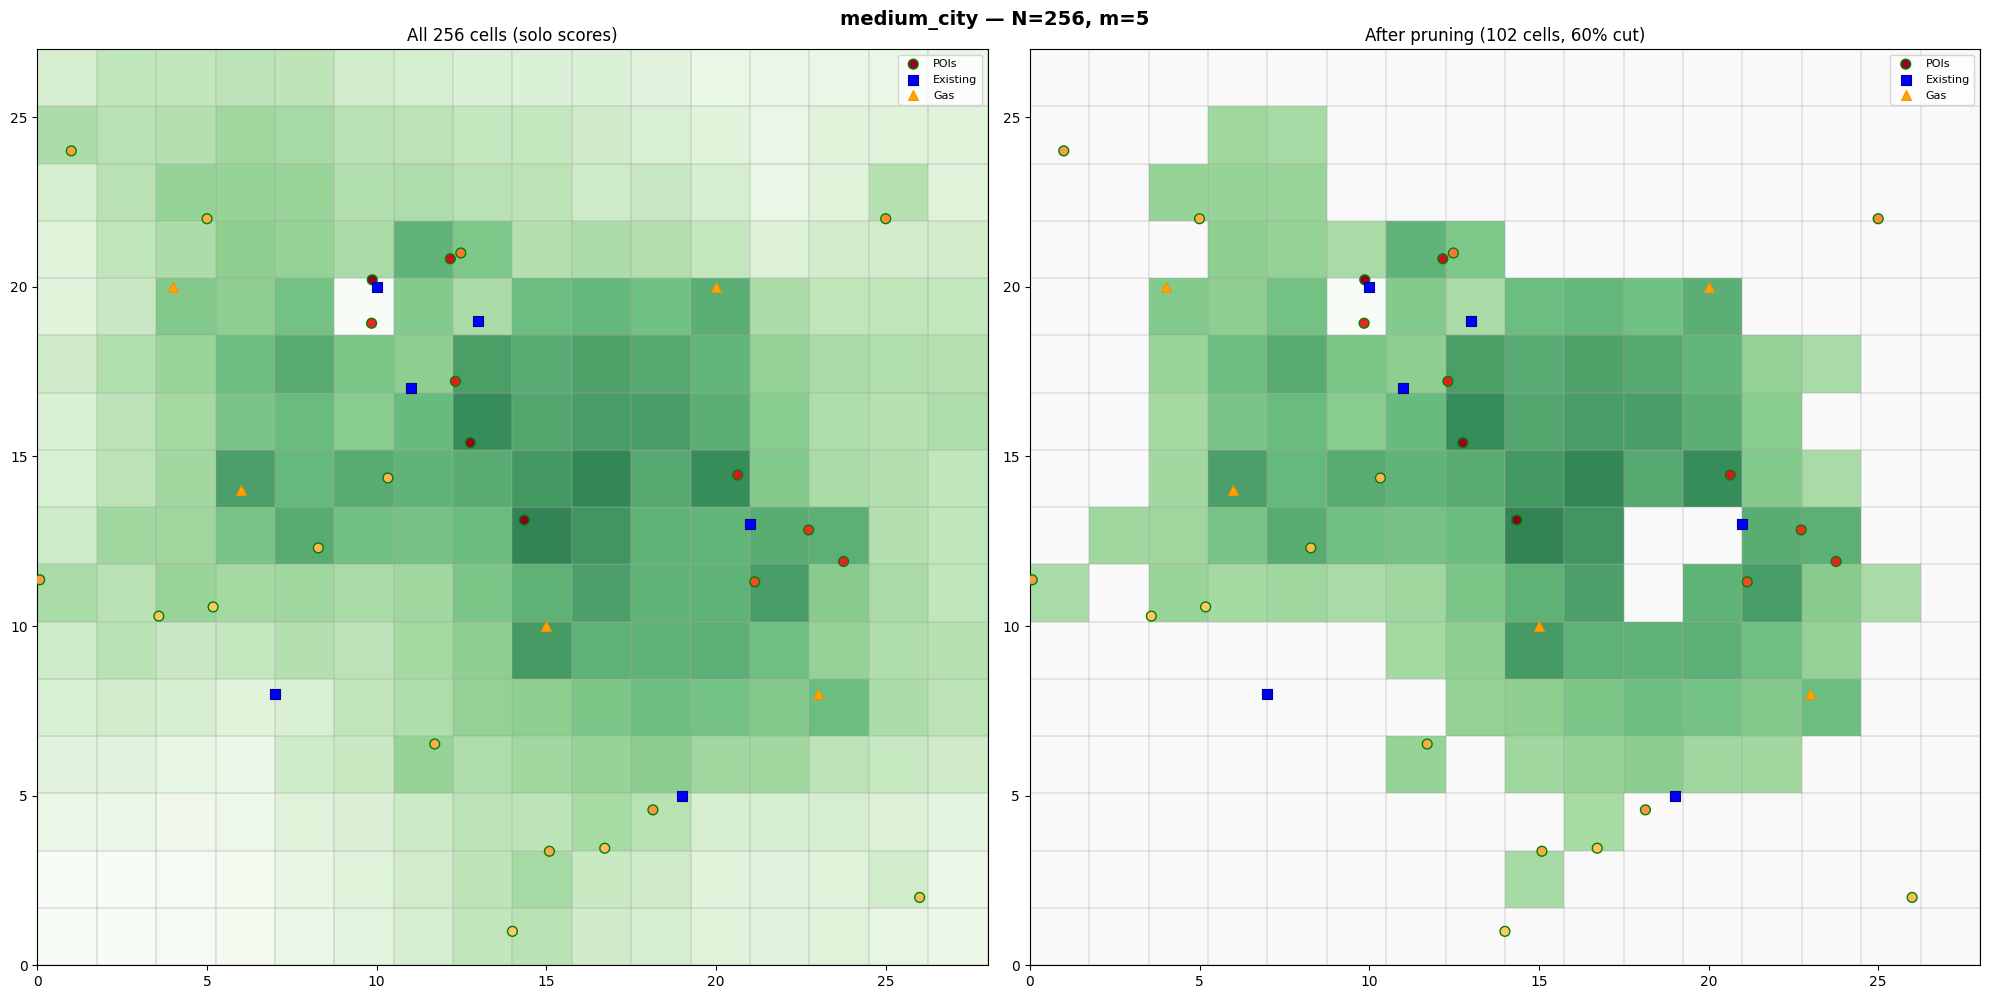

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 12. Pruning visualization
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
solos = compute_solo_scores(Q_obj, N_QUBITS)
num_rows = plot_deets['num_rows']
num_cols = plot_deets['num_cols']
cell_w = plot_deets['cell_w']
cell_h = plot_deets['cell_h']

for ax_idx, (ax, title, highlight) in enumerate(zip(
    axes,
    [f'All {N_QUBITS} cells (solo scores)',
     f'After pruning ({K} cells, {100*(1-K/N_QUBITS):.0f}% cut)'],
    [set(range(N_QUBITS)), set(surviving_cells)],
)):
    ax.set_facecolor('white')
    for i in range(num_cols + 1):
        ax.axvline(x=X_MIN + i * cell_w, color='gray', linestyle='-', linewidth=0.2)
    for j in range(num_rows + 1):
        ax.axhline(y=Y_MIN + j * cell_h, color='gray', linestyle='-', linewidth=0.2)

    for gid, info in grid_details.items():
        if gid in highlight:
            score = solos[gid]
            norm = max(0, min(1, -score / 3.0))
            color = plt.cm.Greens(norm)
            alpha = 0.8
        else:
            color = (0.93, 0.93, 0.93)
            alpha = 0.3
        ax.add_patch(plt.Rectangle(
            (info['x_start'], info['y_start']), cell_w, cell_h,
            facecolor=color, alpha=alpha, edgecolor='lightgray', linewidth=0.2,
        ))

    if points_of_interest:
        ax.scatter([p[0] for p in points_of_interest],
                   [p[1] for p in points_of_interest],
                   c=[p[2] for p in points_of_interest], cmap='YlOrRd',
                   edgecolors='green', linewidths=1, s=50, vmin=0, vmax=1,
                   zorder=5, label='POIs')
    if existing_charging_points:
        ax.scatter(*zip(*existing_charging_points), color='blue', marker='s',
                   s=50, zorder=5, edgecolors='darkblue', linewidths=0.8, label='Existing')
    if gas_stations:
        ax.scatter(*zip(*gas_stations), color='orange', marker='^',
                   s=50, zorder=5, edgecolors='darkorange', linewidths=0.8, label='Gas')

    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_aspect('equal')

plt.suptitle(f"{data['dataset_name']} — N={N_QUBITS}, m={M}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 13. Summary
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 70)
print("PIPELINE SUMMARY")
print("=" * 70)
print(f"  Dataset:    {data['dataset_name']}")
print(f"  Grid:       {N_QUBITS} cells ({plot_deets['num_rows']}×{plot_deets['num_cols']})")
print(f"  POIs:       {len(points_of_interest)}")
print(f"  Chargers:   {len(existing_charging_points)} existing, {M} new to place")
print(f"  Gas:        {len(gas_stations)}")
print(f"  Pruning:    {N_QUBITS} → {K} ({100*(1-K/N_QUBITS):.0f}% reduction)")
print(f"    Tier 1:   {prune_report['tier1']['pruned']} pruned")
print(f"    Tier 2:   {prune_report['tier2']['pruned']} pruned")
print(f"    Tier 3:   {prune_report['tier3']['pruned']} pruned")
print(f"  Search:     C({N_QUBITS},{M})={math.comb(N_QUBITS,M):,} → "
      f"C({K},{M})={math.comb(K,M):,}")

if full_optimal_score is not None:
    print(f"  BF optimal: {full_optimal_score:.4f} cells={sorted(full_optimal_cells)}")
if qaoa_results_cells:
    print(f"  QAOA best:  {qaoa_results_cells[0][0]:.4f} cells={qaoa_results_cells[0][1]}")
print("=" * 70)

PIPELINE SUMMARY
  Dataset:    medium_city
  Grid:       256 cells (16×16)
  POIs:       25
  Chargers:   6 existing, 5 new to place
  Gas:        5
  Pruning:    256 → 102 (60% reduction)
    Tier 1:   0 pruned
    Tier 2:   151 pruned
    Tier 3:   3 pruned
  Search:     C(256,5)=8,809,549,056 → C(102,5)=83,291,670
